<a href="https://colab.research.google.com/github/MDankloff/Delayed-Fairness-Project/blob/main/BAF_graph_sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Network sensitivity analysis on BAF calibrated Base data, reusing the BAF pipeline built in BAF_Base, BAF_Variant1, BAF_V2 and combined with graph_sensitivity.py (ER,WS,SBM,BA generators)

The analysis is run on all three datasets (Base, Variant 1, Variant 2), using the unconstrained (Baseline) model.

This tests whether network sensitivity interact with bias magnitude, motivated by finding that fairness-constrained models behave differently on near-zero-bias
data (Variant I) versus real-bias data (Base) and increased bias (Variant II).

In [8]:
import os, sys

repo_url = "https://github.com/MDankloff/Delayed-Fairness-Project.git"
repo_dir = "/content/Delayed-Fairness-Project"
if not os.path.exists(repo_dir):
    os.system(f"git clone {repo_url} {repo_dir}")
else:
    os.system(f"git -C {repo_dir} pull origin main")
src_path = os.path.join(repo_dir, "Synthetic", "src")
assert os.path.exists(os.path.join(src_path, "generator.py"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print("Using:", src_path)


Using: /content/Delayed-Fairness-Project/Synthetic/src


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

import generator as gen_mod
from generator import Agent as GenAgentBase
from simulator import Bank, Agent as SimAgentBase
from baselines import LR
from utils import combine_tuples, sampling as _sampling
from graph_sensitivity import (
    gen_demographic_regular_graph_robust, gen_ws_block_graph,
    gen_er_graph, graph_diagnostics
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [10]:
# Agent classes + credit limit coupling helper

class _BAFInitMixin:
  def __init__(self, s_pool, X_pool, n_samples, protect_ratio=0.5, eps=0.5, base=(0.2, 1.0), seed=2026):
    super().__init__(n_samples=n_samples,protect_ratio=protect_ratio, eps=eps, base=base, seed=seed)
    self._s_pool = s_pool
    self._X_pool = X_pool

  def gen_init_profile(self):
    # build one simulated 'population' for the simulation by drawing real BAF applicants at random, half from each group
    rng = np.random.default_rng(self.seed)
    n0 = np.where(self._s_pool == 0)[0]
    n1 = np.where(self._s_pool == 1)[0]
    half = self.n_samples // 2
    idx0 = rng.choice(n0, size=half, replace=False)
    idx1 = rng.choice(n1, size=self.n_samples - half, replace=False)
    idx = np.concatenate([idx0, idx1])
    rng.shuffle(idx)
    return self._s_pool[idx].astype(float), self._X_pool[idx].copy()

class BAFAgentGen(_BAFInitMixin, GenAgentBase):
  pass

class BAFAgentSim(_BAFInitMixin, SimAgentBase):
  pass

In [11]:
from sklearn.linear_model import LinearRegression as _LinReg
_credit_col, _limit_col = 0, 1

def make_resync_fn(df):
  # fit the credit_risk_score <-> proposed_credit_limit coupling once (0,606 for Base), and return resync_credit_limit function
  coupling_model = _LinReg().fit(df[['credit_risk_score']].to_numpy(), df['proposed_credit_limit'].to_numpy())
  residual_std = (df['proposed_credit_limit']- coupling_model.predict(df[['credit_risk_score']].to_numpy())).std()
  credit_mean, credit_std = df['credit_risk_score'].mean(), df['credit_risk_score'].std()
  limit_mean, limit_std = df['proposed_credit_limit'].mean(), df['proposed_credit_limit'].std()

  def resync_credit_limit(X_next, rng):
      X_next = np.asarray(X_next, dtype=float)
      credit_raw = X_next[:, _credit_col] * credit_std + credit_mean
      predicted_limit_raw = coupling_model.predict(credit_raw.reshape(-1, 1))
      noise = rng.normal(0, residual_std, size=len(credit_raw))
      limit_raw = predicted_limit_raw + noise
      X_next = X_next.copy()
      X_next[:, _limit_col] = (limit_raw - limit_mean) / limit_std
      return X_next

  return resync_credit_limit

if not hasattr(gen_mod.Agent, '_original_gen_next_profile'):
  gen_mod.Agent._original_gen_next_profile = gen_mod.Agent.gen_next_profile


In [12]:
# run_simulation_with_graph accepts a pre-built adjacency matrix instead of building one internally from k_same/k_other
# Testing SEVERAL different kinds of networks (Erdos-Renyi, Watts-Strogatz, and our regular network), so the network needs to be
# built beforehand, rather than built automatically inside the simulation.
#

def run_simulation_with_graph(decision_model, agent, steps, adj, resync_fn, *, repayment_model = None, seed=2026, decision_coef= 0.8, repayment_coef=0.8):

  # Falls back on default if no ground truth is given
  if repayment_model is None:
    repayment_model = Bank ()

  # Get the starting population: everyone's group (s) and starting features (X), credit score & limit
  s, X = agent.gen_init_profile()
  s = np.asarray(s).astype(int)
  X = np.asarray(X, dtype=float)
  n = len(s)
  adj = np.asarray(adj)

  _, p_y = repayment_model.predict(s, X)
  Y = _sampling(np.asarray(p_y, dtype=float), values=[0.0, 1.0], coef=float(repayment_coef)).astype(int)

  # Decide for each applicant, whether they actually repay or default - hidden for bank

  active = np.ones(n, dtype=int)
  prev_denied = np.zeros(n, dtype=int)
  Xs, Ys = [X], [Y]
  As = []

  for t in range(int(steps)):
    X_t, Y_t, A_t, P_t = Xs[-1], Ys[-1], active, prev_denied

    _, p_dec = decision_model.predict(s, X_t)
    D_t = _sampling(np.asarray(p_dec, dtype=float), values=[0.0, 1.0], coef=float(decision_coef)).astype(int)
    D_t[A_t == 0] = -1
    denied = ((A_t == 1) & (D_t == 0)).astype(int)

  # Bank looks at each applicants current features and decides: approve or deny
    O_t = agent.compute_observed_rejection_gap(adj, D_t, s, active=A_t, exclude_inactive_from_denominator=True)

  # For each applicant, check their network neighbours: is my group getting denied more than the other group, among the people I actually know?
  # Uses adj network
    repeated_denial_no_default = (denied == 1) & (P_t == 1)
    peer_spillover = (denied == 1) & (O_t == 1)
    U_t = ((repeated_denial_no_default | peer_spillover) & (A_t == 1)).astype(int)

  # Some applicant opts out: they were denied and either (a) they were also denied last time, or (b) their peers made it look like their group is being treated unfairly.
    A_next = A_t.copy()
    A_next[(U_t == 1) & (A_t == 1)] = 0

    continue_mask = (A_t == 1) & (A_next == 1)
    outcome_mask = continue_mask & (D_t == 1)

  # Anyone who opted out is marked as no longer active
    X_next = np.asarray(X_t, dtype=float).copy()
    base = np.array([[agent.base[int(i)]] for i in s], dtype=float)
    base_tile = np.tile(base, (1, X_t.shape[1]))
    X_next[continue_mask] = X_t[continue_mask] + base_tile[continue_mask]

    theta = np.asarray(decision_model.params[1:-1], dtype=float)
    repay_sign = (2.0 * Y_t - 1.0).reshape(-1, 1)
    delta = np.repeat(agent.eps * theta.reshape(1, -1), repeats=n, axis=0) * repay_sign

  # Applicants who are still around gets a small, automatic feature bump (representing normal financial "aging").
    X_next[outcome_mask] = X_next[outcome_mask] + delta[outcome_mask]

  # + Applicants who got approved and actually repaid gets a bigger boost; anyone who defaulted gets pushed down instead.
    X_next = resync_fn(X_next, np.random)

 # Fix up the credit limit so it still matches the credit score realistically
    Y_next = np.asarray(Y_t, dtype=int).copy()
    if continue_mask.any():
      _, p_y_next = repayment_model.predict(s, X_next)
      Y_sample = _sampling(np.asarray(p_y_next, dtype=float), values=[0.0, 1.0], coef=float(repayment_coef)).astype(int)
      Y_next[continue_mask] = Y_sample[continue_mask]

      P_next = denied.copy()
      P_next[A_next == 0] = 0

      As.append(A_t.copy())
      active, prev_denied = A_next, P_next
      if t < steps - 1:
        Xs.append(X_next); Ys.append(Y_next)

    As.append(active.copy())  # final state
    return s, Xs, Ys, As


In [13]:
# Take the last recorded active/inactive list, what percentage of each group is still around, and return how far apart those two percentages are
def final_disparity(s, As):
    s = np.asarray(s).astype(int)
    A_final = np.asarray(As[-1])
    r0 = A_final[s == 0].mean() * 100
    r1 = A_final[s == 1].mean() * 100
    return abs(r0 - r1)


# Sensitivity analysis
run on all three datasets, using unconstrained baseline mode.
tests whether network sensitivity itself interacts with underlying bias magnitude

Mounted at /content/drive
Base: calibrated, group balance = [250 250]
Variant I: calibrated, group balance = [250 250]
Variant II: calibrated, group balance = [250 250]
               mean       std
dataset    k                 
Base       4   3.40  2.093376
           6   3.16  2.656313
           8   4.64  2.958678
           10  5.00  3.828548
           14  4.12  4.357573
           20  7.36  4.474918
Variant I  4   2.40  2.065591
           6   2.84  2.078033
           8   4.28  3.780888
           10  3.24  2.320536
           14  4.60  3.195831
           20  4.16  2.459991
Variant II 4   2.68  3.023170
           6   3.16  3.279295
           8   4.92  2.501910
           10  5.68  4.303177
           14  6.48  3.621172
           20  7.04  6.425505
                  mean       std
dataset    ratio                
Base       0.5    3.72  3.172381
           0.6    6.28  4.250176
           0.7    7.04  5.815535
           0.8    4.56  2.854704
           0.9    1.88  0.943751


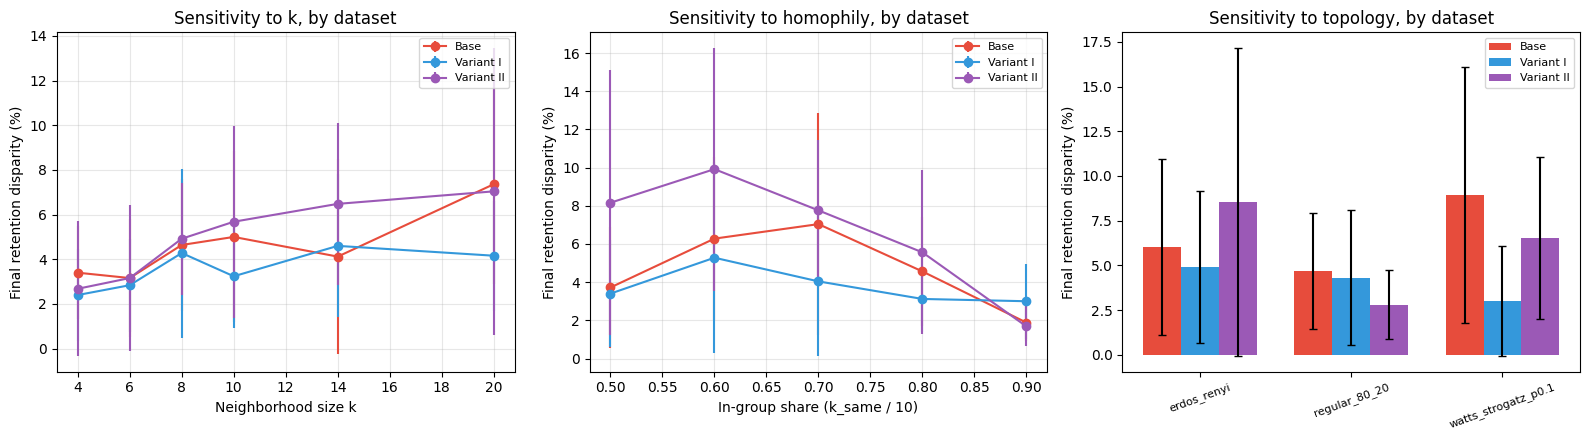

In [14]:
def setup_baf_dataset(df, resync_fn, X_COLS=('credit_risk_score', 'proposed_credit_limit'),
                       n_train=4000, n_test=500, steps=5):
    """Calibrate Bank + train Baseline (LR) for one BAF dataset. `resync_fn`
    is the credit-limit coupling function (from Base).
    Real correlation is close across all three datasets (0.606/0.599/0.631)
    Returns everything eval_graph_config_for needs: bank, lr, agent_test, s_ref.
    """
    d = df[['fraud_bool', 'customer_age'] + list(X_COLS)].copy()
    d['S'] = (d['customer_age'] >= 50).astype(int)

    X_all = d[list(X_COLS)].to_numpy(dtype=float)
    X_all = (X_all - X_all.mean(axis=0)) / X_all.std(axis=0)
    s_all = d['S'].to_numpy(dtype=int)
    y_all = d['fraud_bool'].to_numpy(dtype=int)

    clf = LogisticRegression(max_iter=1000).fit(np.c_[s_all, X_all], 1 - y_all)
    w_s, w_x1, w_x2 = clf.coef_[0]
    w_0 = clf.intercept_[0]
    bank_d = Bank(params=np.array([w_s, w_x1, w_x2, w_0]))
    gen_mod.Bank.params = np.array([w_s, w_x1, w_x2, w_0])
    Bank.params = np.array([w_s, w_x1, w_x2, w_0])

    def _resynced_gen_next_profile(self, s, X, model, _resync=resync_fn):
        X_next = gen_mod.Agent._original_gen_next_profile(self, s, X, model)
        return _resync(np.asarray(X_next, dtype=float), np.random)
    gen_mod.Agent.gen_next_profile = _resynced_gen_next_profile

    agent_train_d = BAFAgentGen(s_all, X_all, n_samples=n_train, eps=0.5, base=[0.2, 1.0], seed=2026)
    agent_test_d  = BAFAgentSim(s_all, X_all, n_samples=n_test,  eps=0.5, base=[0.2, 1.0], seed=2027)

    s_train, Xs_train, Ys_train = gen_mod.gen_multi_step_profiles(bank_d, agent_train_d, steps=steps)
    s_comb, X_comb, Y_comb = combine_tuples(s_train, Xs_train, Ys_train)
    lr_d = LR(l2_reg=1e-5)
    lr_d.train(s_comb, X_comb, Y_comb)

    s_ref_d, _ = agent_test_d.gen_init_profile()
    s_ref_d = np.asarray(s_ref_d).astype(int)

    return bank_d, lr_d, agent_test_d, s_ref_d


# Load all three BAF datasets
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF/parquet data'
datasets = {
    'Base':       pd.read_parquet(f"{base_path}/Base.parquet"),
    'Variant I':  pd.read_parquet(f"{base_path}/Variant I.parquet"),
    'Variant II': pd.read_parquet(f"{base_path}/Variant II.parquet"),
}

# Fit the credit-limit coupling across all three datasets
shared_resync_fn = make_resync_fn(datasets['Base'])

# Calibrate all three datasets once
dataset_setups = {}
for name, df in datasets.items():
    bank_d, lr_d, agent_test_d, s_ref_d = setup_baf_dataset(df, shared_resync_fn)
    dataset_setups[name] = {'bank': bank_d, 'lr': lr_d, 'agent_test': agent_test_d, 's_ref': s_ref_d}
    print(f"{name}: calibrated, group balance = {np.bincount(s_ref_d)}")


def eval_graph_config_for(name, adj, seed):
    setup = dataset_setups[name]
    s, Xs, Ys, As = run_simulation_with_graph(
        setup['lr'], setup['agent_test'], 5, adj, shared_resync_fn,
        repayment_model=setup['bank'], seed=seed
    )
    disp = final_disparity(s, As)
    diag = graph_diagnostics(adj, s=s)
    return disp, diag

# NEIGBORHOOD SIZE k, homophily fixed at 80/20, ALL 3 DATASETS
N_SEEDS = 10 #5
rows_A = []
for name in datasets:
    s_ref = dataset_setups[name]['s_ref']
    for k in [4, 6, 8, 10, 14, 20]:
        k_same = int(round(0.8 * k)); k_other = k - k_same
        for sd in range(N_SEEDS):
            adj, _ = gen_demographic_regular_graph_robust(s_ref, k_same=k_same, k_other=k_other, seed=1000 + sd)
            disp, diag = eval_graph_config_for(name, adj, seed=1000 + sd)
            rows_A.append({'dataset': name, 'k': k, 'seed': sd, 'disparity': disp, **diag})

df_A = pd.DataFrame(rows_A)
print(df_A.groupby(['dataset', 'k'])['disparity'].agg(['mean', 'std']))

# HOMOPHILY RATIO, k fixed at 10, ALL 3 DATASETS
rows_B = []
for name in datasets:
    s_ref = dataset_setups[name]['s_ref']
    for k_same in [5, 6, 7, 8, 9]:
        k_other = 10 - k_same
        for sd in range(N_SEEDS):
            adj, _ = gen_demographic_regular_graph_robust(s_ref, k_same=k_same, k_other=k_other, seed=1000 + sd)
            disp, diag = eval_graph_config_for(name, adj, seed=1000 + sd)
            rows_B.append({'dataset': name, 'ratio': k_same / 10.0, 'seed': sd, 'disparity': disp, **diag})

df_B = pd.DataFrame(rows_B)
print(df_B.groupby(['dataset', 'ratio'])['disparity'].agg(['mean', 'std']))

# TOPOLOGY FAMILY, k=10, ~80/20, ALL 3 DATASETS.
# Two models: Erdos-Renyi (1959, foundational random-graph model) and Watts-Strogatz (1998, "small-world"), compared against the main regular-graph
# generator used throughout this project.
rows_C = []
for name in datasets:
    s_ref = dataset_setups[name]['s_ref']
    for sd in range(N_SEEDS):
        seed = 1000 + sd
        configs = {
            'erdos_renyi': gen_er_graph(len(s_ref), k=10, seed=seed)[0],
            'regular_80_20': gen_demographic_regular_graph_robust(s_ref, k_same=8, k_other=2, seed=seed)[0],
            'watts_strogatz_p0.1': gen_ws_block_graph(s_ref, k_same=8, k_other=2, rewire_p=0.1, seed=seed)[0],
        }
        for topo_name, adj in configs.items():
            disp, diag = eval_graph_config_for(name, adj, seed=seed)
            rows_C.append({'dataset': name, 'topology': topo_name, 'seed': sd, 'disparity': disp, **diag})

df_C = pd.DataFrame(rows_C)
print(df_C.groupby(['dataset', 'topology'])['disparity'].agg(['mean', 'std']))

# %% FIGURES  one line per dataset, Showing if network sensitivity interacts with bias magnitude
dataset_colors = {'Variant I': '#3498DB', 'Base': '#E74C3C', 'Variant II': '#9B59B6'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for name in datasets:
    a = df_A[df_A.dataset == name].groupby('k')['disparity'].agg(['mean', 'std']).reset_index()
    axes[0].errorbar(a['k'], a['mean'], yerr=a['std'], marker='o', label=name, color=dataset_colors[name])
axes[0].set_xlabel('Neighborhood size k'); axes[0].set_ylabel('Final retention disparity (%)')
axes[0].set_title('Sensitivity to k, by dataset'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name in datasets:
    b = df_B[df_B.dataset == name].groupby('ratio')['disparity'].agg(['mean', 'std']).reset_index()
    axes[1].errorbar(b['ratio'], b['mean'], yerr=b['std'], marker='o', label=name, color=dataset_colors[name])
axes[1].set_xlabel('In-group share (k_same / 10)'); axes[1].set_ylabel('Final retention disparity (%)')
axes[1].set_title('Sensitivity to homophily, by dataset'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

width = 0.25
topo_names = ['erdos_renyi', 'regular_80_20', 'watts_strogatz_p0.1']
x = np.arange(len(topo_names))
for i, name in enumerate(datasets):
    c_mean = df_C[df_C.dataset == name].groupby('topology')['disparity'].mean().reindex(topo_names)
    c_std = df_C[df_C.dataset == name].groupby('topology')['disparity'].std().reindex(topo_names)
    axes[2].bar(x + i * width, c_mean, width, yerr=c_std, label=name, color=dataset_colors[name], capsize=3)
axes[2].set_xticks(x + width); axes[2].set_xticklabels(topo_names, rotation=20, fontsize=8)
axes[2].set_ylabel('Final retention disparity (%)')
axes[2].set_title('Sensitivity to topology, by dataset'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('baf_graph_sensitivity_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()